# Pandas, NumPy, and Data Visualization Exercises

## Level

Intermediate

## Scenario

You are analyzing orders from an international e-commerce company. The file
`ecommerce_orders.csv` contains order data from 2024 and 2025.

The dataset contains a few realistic problems such as missing values, duplicate
rows, invalid values, and unusually large prices.

This version focuses on practical skills and avoids highly advanced topics such
as cohort analysis, bootstrap simulation, and complex customer segmentation.

## Main Skills

- Reading and inspecting data
- Simple missing-value handling
- Filtering and sorting
- Creating calculated columns
- GroupBy and Pivot Table
- Basic time-series analysis
- NumPy conditions
- Matplotlib and Pandas charts


## Setup

Keep `ecommerce_orders.csv` in the same folder as the notebook and run the cell
below before answering the questions.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

DATA_PATH = Path("ecommerce_orders.csv")
assert DATA_PATH.exists(), "Place ecommerce_orders.csv next to this notebook."

df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)
df_raw.head()


Dataset shape: (6024, 21)


,order_id,order_date,ship_date,customer_id,customer_segment,country,city,channel,device,campaign,category,subcategory,product_id,unit_price,unit_cost,quantity,discount_pct,shipping_cost,payment_method,returned,satisfaction_score
0,ORD-002245,2025-04-30,2025-05-05,C00472,Consumer,Iran,Isfahan,Marketplace,Mobile,Search Ads,Home,Decor,HOM-DEC-003,139.31,122.59,1,0.07,7.98,Card,False,4.00
1,ORD-002874,2024-04-28,2024-05-02,C00637,Small Business,Iran,Shiraz,Website,Mobile,Organic,Sports,Fitness,SPO-FIT-134,57.08,35.77,2,0.01,15.13,Bank Transfer,False,4.00
2,ORD-003673,2024-03-29,2024-04-05,C00742,Consumer,Iran,Shiraz,Mobile App,iOS,Search Ads,Beauty,Makeup,BEA-MAK-046,112.00,68.36,1,0.27,11.41,Bank Transfer,False,3.00
3,ORD-000817,2024-04-23,2024-04-28,C00493,Small Business,Iran,Tehran,Website,Desktop,Email,Books,Fiction,BOO-FIC-104,10.14,7.21,8,0.09,14.43,Card,False,5.00
4,ORD-005651,2024-03-08,2024-03-09,C01240,Consumer,Iran,Tehran,Mobile App,Android,Organic,Beauty,Fragrance,BEA-FRA-003,11.21,7.78,1,0.02,6.03,Bank Transfer,False,5.00


## Data Dictionary

| Column | Description |
|---|---|
| `order_id` | Order identifier |
| `order_date` | Date of the order |
| `ship_date` | Shipping date |
| `customer_id` | Customer identifier |
| `customer_segment` | Customer type |
| `country`, `city` | Customer location |
| `channel`, `device` | Purchase channel and device |
| `campaign` | Marketing source |
| `category`, `subcategory` | Product category and subcategory |
| `unit_price`, `unit_cost` | Selling price and cost per unit |
| `quantity` | Number of items |
| `discount_pct` | Discount as a decimal value |
| `shipping_cost` | Shipping cost |
| `returned` | Whether the order was returned |
| `satisfaction_score` | Satisfaction score from 1 to 5 |


## Question 1 — Explore the Dataset

Display:

- The first 10 rows
- The number of rows and columns
- Column names
- Data types
- A basic statistical summary for numerical columns

Write one short comment about what you notice.

In [4]:
df_raw.head(10)


,order_id,order_date,ship_date,customer_id,customer_segment,country,city,channel,device,campaign,category,subcategory,product_id,unit_price,unit_cost,quantity,discount_pct,shipping_cost,payment_method,returned,satisfaction_score
0,ORD-002245,2025-04-30,2025-05-05,C00472,Consumer,Iran,Isfahan,Marketplace,Mobile,Search Ads,Home,Decor,HOM-DEC-003,139.31,122.59,1,0.07,7.98,Card,False,4.00
1,ORD-002874,2024-04-28,2024-05-02,C00637,Small Business,Iran,Shiraz,Website,Mobile,Organic,Sports,Fitness,SPO-FIT-134,57.08,35.77,2,0.01,15.13,Bank Transfer,False,4.00
2,ORD-003673,2024-03-29,2024-04-05,C00742,Consumer,Iran,Shiraz,Mobile App,iOS,Search Ads,Beauty,Makeup,BEA-MAK-046,112.00,68.36,1,0.27,11.41,Bank Transfer,False,3.00
3,ORD-000817,2024-04-23,2024-04-28,C00493,Small Business,Iran,Tehran,Website,Desktop,Email,Books,Fiction,BOO-FIC-104,10.14,7.21,8,0.09,14.43,Card,False,5.00
4,ORD-005651,2024-03-08,2024-03-09,C01240,Consumer,Iran,Tehran,Mobile App,Android,Organic,Beauty,Fragrance,BEA-FRA-003,11.21,7.78,1,0.02,6.03,Bank Transfer,False,5.00
5,ORD-005736,2025-10-10,2025-10-14,C00325,Consumer,Iran,Tabriz,Website,Desktop,Social Ads,Electronics,Mobile,ELE-MOB-052,141.27,78.35,1,0.22,7.83,Card,True,3.00
6,ORD-005350,2024-01-06,2024-01-13,C01803,Small Business,Germany,Hamburg,Website,Desktop,Social Ads,Books,Business,BOO-BUS-105,23.91,16.01,1,0.09,13.60,Card,False,4.00
7,ORD-003931,2025-12-17,2025-12-21,C01029,Consumer,Iran,Tehran,Marketplace,Mobile,NaN,Electronics,Laptop,ELE-LAP-006,"1,586.79","1,118.69",2,0.10,8.38,Bank Transfer,False,4.00
8,ORD-001468,2025-10-03,2025-10-10,C01055,Corporate,Germany,Frankfurt,Mobile App,iOS,Search Ads,Sports,Running,SPO-RUN-085,209.16,143.78,4,0.03,15.79,Cash on Delivery,False,4.00
9,ORD-002729,2024-02-25,2024-02-29,C00102,Consumer,Germany,Frankfurt,Marketplace,Mobile,Organic,Books,Fiction,BOO-FIC-101,53.34,37.29,1,0.08,11.61,Card,False,4.00


In [5]:
rows, cols = df_raw.shape
print("Rows:", rows)
print("Columns:", cols)

Rows: 6024
Columns: 21


In [6]:
df_raw.columns

Index(['order_id', 'order_date', 'ship_date', 'customer_id',
       'customer_segment', 'country', 'city', 'channel', 'device', 'campaign',
       'category', 'subcategory', 'product_id', 'unit_price', 'unit_cost',
       'quantity', 'discount_pct', 'shipping_cost', 'payment_method',
       'returned', 'satisfaction_score'],
      dtype='str')

In [7]:
df_raw.dtypes

order_id                  str
order_date                str
ship_date                 str
customer_id               str
customer_segment          str
country                   str
city                      str
channel                   str
device                    str
campaign                  str
category                  str
subcategory               str
product_id                str
unit_price            float64
unit_cost             float64
quantity                int64
discount_pct          float64
shipping_cost         float64
payment_method            str
returned                 bool
satisfaction_score    float64
dtype: object

In [8]:
df_raw.describe()
#The order_date and ship_date columns are stored as strings and should be converted to datetime for time-based analysis.

,unit_price,unit_cost,quantity,discount_pct,shipping_cost,satisfaction_score
count,"6,024.00","6,024.00","6,024.00","5,969.00","6,024.00","5,879.00"
mean,443.91,293.39,2.35,0.10,11.52,4.23
std,550.53,320.31,1.96,0.08,4.35,0.68
min,6.31,3.23,-1.00,-0.10,4.96,1.00
25%,80.78,53.51,1.00,0.04,8.38,4.00
50%,258.56,171.62,2.00,0.08,10.86,4.00
75%,583.82,389.24,3.00,0.14,13.53,5.00
max,"15,898.09","1,523.88",10.00,1.20,37.10,5.00


## Question 2 — Find Missing Values and Duplicates

Create a table showing the number and percentage of missing values in
each column.

Also calculate:

- The number of exact duplicate rows
- The number of duplicated `order_id` values

Do not clean the data yet.

In [9]:
missinig_count=df_raw.isnull().sum()
missinig_percent=df_raw.isnull().mean()*100
missing_table=pd.DataFrame({"Missing Count": missinig_count,"Missing Percentage": missinig_percent})
missing_table

,Missing Count,Missing Percentage
order_id,0,0.00
order_date,0,0.00
ship_date,0,0.00
customer_id,0,0.00
customer_segment,0,0.00
country,0,0.00
city,95,1.58
channel,0,0.00
device,0,0.00
campaign,120,1.99


In [10]:
duplicate_rows=df_raw.duplicated().sum()
print("duplicate_rows:",duplicate_rows)
duplicate_order_ids=df_raw["order_id"].duplicated().sum()
print("duplicate order ids:",duplicate_order_ids)

duplicate_rows: 24
duplicate order ids: 24


## Question 3 — Simple Missing-Value Handling

Create a copy named `df` and apply these simple rules:

- Fill missing `city` values with `"Unknown"`.
- Fill missing `campaign` values with `"Unknown"`.
- Fill missing `discount_pct` values with `0`.
- Fill missing `satisfaction_score` values with the overall median score.

Finally, verify that these four columns no longer contain missing values.

In [11]:
df=df_raw.copy()
df['city']=df['city'].fillna('Unknown')
df['campaign']=df['campaign'].fillna('Unknown')
df['discount_pct']=df['discount_pct'].fillna('0')
median_score=df['satisfaction_score'].median
df['satisfaction_score']=df['satisfaction_score'].fillna(median_score)
print(df[["city", "campaign", "discount_pct", "satisfaction_score"]].isnull().sum())
h=len(df)

city                  0
campaign              0
discount_pct          0
satisfaction_score    0
dtype: int64


## Question 4 — Convert Dates and Remove Bad Rows

Perform the following cleaning steps:

1. Convert `order_date` and `ship_date` to datetime.
2. Remove exact duplicate rows.
3. Keep only rows where:
   - `quantity` is greater than zero.
   - `discount_pct` is between 0 and 1.
   - `ship_date` is equal to or later than `order_date`.

Display the number of rows before and after cleaning.

In [12]:
print('Rows before cleaning:',h)
df['order_date']=pd.to_datetime(df['order_date'])
df['ship_date']=pd.to_datetime(df['ship_date'])
df=df.drop_duplicates()
df=df[df['quantity']>0]
df['discount_pct']=pd.to_numeric(df['discount_pct'])
df=df[(df['discount_pct']>=0) & (df['discount_pct']<=1)]
df=df[df['ship_date']>=df['order_date']]
print('Rows after cleaning:', len(df))

Rows before cleaning: 6024
Rows after cleaning: 5970


## Question 5 — Create New Columns

Create these columns:

- `delivery_days`
- `gross_sales = unit_price × quantity`
- `net_sales = gross_sales × (1 - discount_pct)`
- `total_cost = unit_cost × quantity + shipping_cost`
- `profit = net_sales - total_cost`
- `order_month`

Display five rows containing the new columns.

In [13]:
df['delivery_days']=(df['ship_date']-df['order_date']).dt.days
df['gross_sales']=df['unit_price']*df['quantity']
df['net_sales']=df['gross_sales']*(1-df['discount_pct'])
df['total_cost']=df['unit_cost']*df['quantity']+df['shipping_cost']
df['profit']=df['net_sales']-df['total_cost']
df['order_month']=df['order_date'].dt.month
df[["delivery_days","gross_sales","net_sales","total_cost","profit","order_month"
]].head()

,delivery_days,gross_sales,net_sales,total_cost,profit,order_month
0,5,139.31,129.28,130.57,-1.29,4
1,4,114.16,113.45,86.67,26.78,4
2,7,112.00,81.88,79.77,2.11,3
3,5,81.12,73.47,72.11,1.36,4
4,1,11.21,10.99,13.81,-2.82,3


## Question 6 — Use NumPy Conditions

Create a new column named `sales_level` using `np.select`:

- `"Low"` for `net_sales` below 100
- `"Medium"` for `net_sales` from 100 to below 500
- `"High"` for `net_sales` from 500 to below 1000
- `"Very High"` for `net_sales` of 1000 or more

Display the number of orders in each sales level.

In [14]:
conditions = [
    df["net_sales"] < 100,
    (df["net_sales"] >= 100) & (df["net_sales"] < 500),
    (df["net_sales"] >= 500) & (df["net_sales"] < 1000),
    df["net_sales"] >= 1000
]
choices=["Low","Medium","High","Very High"]
df['sales_level']=np.select(conditions,choices,default="Unknown")
print(df['sales_level'].value_counts())

sales_level
Medium       2179
Very High    1599
Low          1222
High          970
Name: count, dtype: int64


## Question 7 — Filter and Sort Orders

Find orders that meet all of these conditions:

- Category is `Electronics`
- Net sales are greater than 500
- The order was not returned

Sort the result by `net_sales` from highest to lowest and display the first 15
rows.

In [15]:
filtered=df[(df['category']=='Electronics')& (df['net_sales']>500) & (~df['returned'])]
filtered=filtered.sort_values(by='net_sales',ascending=False)
filtered.head(15)

,order_id,order_date,ship_date,customer_id,customer_segment,country,city,channel,device,campaign,category,subcategory,product_id,unit_price,unit_cost,quantity,discount_pct,shipping_cost,payment_method,returned,satisfaction_score,delivery_days,gross_sales,net_sales,total_cost,profit,order_month,sales_level
2604,ORD-002283,2024-11-25,2024-11-29,C01003,Small Business,Turkey,Istanbul,Website,Tablet,Organic,Electronics,Headphones,ELE-HEA-102,"15,898.09","1,025.11",6,0.16,18.00,Wallet,False,5.00,4,"95,388.54","79,754.36","6,168.66","73,585.70",11,Very High
2010,ORD-000241,2025-09-09,2025-09-15,C00066,Consumer,Iran,Shiraz,Website,Desktop,Organic,Electronics,Headphones,ELE-HEA-087,"1,582.87","1,199.66",10,0.00,17.12,Cash on Delivery,False,4.00,6,"15,828.70","15,828.70","12,013.72","3,814.98",9,Very High
2118,ORD-005399,2025-02-04,2025-02-08,C00356,Consumer,UAE,Abu Dhabi,Website,Tablet,Affiliate,Electronics,Mobile,ELE-MOB-147,"1,654.23","1,205.85",10,0.04,28.92,Cash on Delivery,False,3.00,4,"16,542.30","15,797.90","12,087.42","3,710.48",2,Very High
2354,ORD-001886,2024-06-22,2024-06-27,C00392,Consumer,Iran,Shiraz,Website,Tablet,Affiliate,Electronics,Laptop,ELE-LAP-118,"1,647.89",830.60,10,0.04,17.61,Wallet,False,5.00,5,"16,478.90","15,750.53","8,323.61","7,426.92",6,Very High
5252,ORD-003051,2024-09-10,2024-09-16,C01769,Small Business,Iran,Tehran,Mobile App,iOS,Affiliate,Electronics,Monitor,ELE-MON-006,"1,698.76","1,336.01",10,0.08,28.16,Cash on Delivery,False,4.00,6,"16,987.60","15,575.93","13,388.26","2,187.67",9,Very High
1538,ORD-000989,2024-03-30,2024-04-07,C00532,Consumer,Iran,Tehran,Mobile App,Android,Organic,Electronics,Mobile,ELE-MOB-040,"1,669.21","1,067.94",10,0.07,22.44,Card,False,4.00,8,"16,692.10","15,496.95","10,701.84","4,795.11",3,Very High
2519,ORD-002363,2024-09-16,2024-09-17,C01225,Small Business,Iran,Mashhad,Website,Mobile,Search Ads,Electronics,Headphones,ELE-HEA-079,"15,802.53",893.73,1,0.05,6.14,Card,False,3.00,1,"15,802.53","14,939.71",899.87,"14,039.84",9,Very High
2011,ORD-003648,2024-07-22,2024-07-27,C00488,Consumer,Iran,Mashhad,Mobile App,iOS,Organic,Electronics,Headphones,ELE-HEA-024,"1,724.92","1,286.50",10,0.16,26.19,Wallet,False,4.00,5,"17,249.20","14,496.23","12,891.19","1,605.04",7,Very High
1977,ORD-002478,2024-11-19,2024-11-26,C01376,Small Business,Iran,Shiraz,Website,Mobile,Search Ads,Electronics,Monitor,ELE-MON-101,"1,521.07","1,023.63",10,0.06,21.79,Wallet,False,4.00,7,"15,210.70","14,354.34","10,258.09","4,096.25",11,Very High
2131,ORD-001120,2024-09-14,2024-09-20,C00871,Consumer,Iran,Mashhad,Mobile App,Android,Search Ads,Electronics,Monitor,ELE-MON-146,"1,460.17",842.90,10,0.02,13.32,Wallet,False,4.00,6,"14,601.70","14,344.71","8,442.32","5,902.39",9,Very High


## Question 8 — Category Summary

Create a summary by `category` containing:

- Number of orders
- Total net sales
- Average net sales
- Total profit
- Average satisfaction score

Sort categories by total net sales from highest to lowest.

In [16]:
df["satisfaction_score"] = df_raw["satisfaction_score"]
median_score = df["satisfaction_score"].median()
df["satisfaction_score"] = df["satisfaction_score"].fillna(median_score)
summary=df.groupby('category').agg({'order_id':"count",'net_sales':['sum','mean'],'profit':'sum',
'satisfaction_score':'mean'})
summary=summary.sort_values(('net_sales','sum'),ascending=False)
summary.head()

order_id    net_sales                profit satisfaction_score
               count          sum     mean          sum               mean
category                                                                  
Electronics     1842 3,879,321.68 2,106.04 1,064,535.85               4.18
Home            1302   945,414.20   726.12   229,555.57               4.24
Sports           958   565,856.93   590.66   144,255.70               4.27
Beauty           886   185,635.34   209.52    40,524.61               4.19
Books            982    99,743.18   101.57    14,433.54               4.25

## Question 9 — Country and Channel Summary

Create a grouped summary for each `country` and `channel` containing:

- Number of orders
- Total net sales
- Average delivery days
- Return rate as a percentage

Display the 15 groups with the highest total net sales.

In [17]:
summary2=df.groupby(['country','channel']).agg({'order_id':'count','net_sales':'sum','delivery_days':'mean',
'returned':'mean'})
summary2['returned']*=100
summary2=summary2.sort_values(by='net_sales',ascending=False)
summary2.head(15)

order_id    net_sales  delivery_days  returned
country channel                                                        
Iran    Website              1352 1,266,070.23           3.96      5.18
        Mobile App           1165 1,136,579.93           3.83      6.18
        Marketplace           560   547,791.83           3.91      7.50
Turkey  Website               440   504,334.14           4.98      6.82
UAE     Website               333   315,563.22           3.52      6.91
Turkey  Mobile App            365   313,235.77           4.87      7.12
Iran    Social Commerce       289   274,536.76           3.92      5.54
UAE     Mobile App            308   274,179.76           3.48      3.57
Germany Website               293   239,794.85           5.43      4.78
        Mobile App            232   212,231.58           5.49      6.47
Turkey  Marketplace           182   187,811.78           5.01      7.69
UAE     Marketplace           116    91,040.79           3.39     10.34
Germany Social Commerce        64    83,122.84           5.28      3.12
        Marketplace           104    79,549.33           5.50      7.69
Turkey  Social Commerce        94    77,834.16           5.05      3.19

## Question 10 — Create a Pivot Table

Create a Pivot Table where:

- Rows are `category`
- Columns are `channel`
- Values are total `net_sales`

Fill missing values with zero and add a `Total` column for each category.

In [18]:
pivot=df.pivot_table(columns='channel',index='category',values='net_sales',aggfunc='sum',fill_value=0)
pivot['total']=pivot.sum(axis=1)
pivot.head()

channel,Marketplace,Mobile App,Social Commerce,Website,total
category,,,,,
Beauty,"30,378.81","74,902.48","16,082.76","64,271.30","185,635.34"
Books,"17,820.28","35,564.65","6,420.23","39,938.03","99,743.18"
Electronics,"656,100.43","1,289,538.31","347,175.26","1,586,507.67","3,879,321.68"
Home,"129,373.95","334,558.50","85,983.92","395,497.82","945,414.20"
Sports,"72,520.27","201,663.10","52,125.95","239,547.62","565,856.93"


## Question 11 — Monthly Sales Trend

Calculate total `net_sales` for each month.

Then:

- Sort the result by month
- Calculate month-over-month percentage change
- Display the last 12 months
- Plot monthly net sales as a line chart

<function matplotlib.pyplot.show(close=None, block=None)>

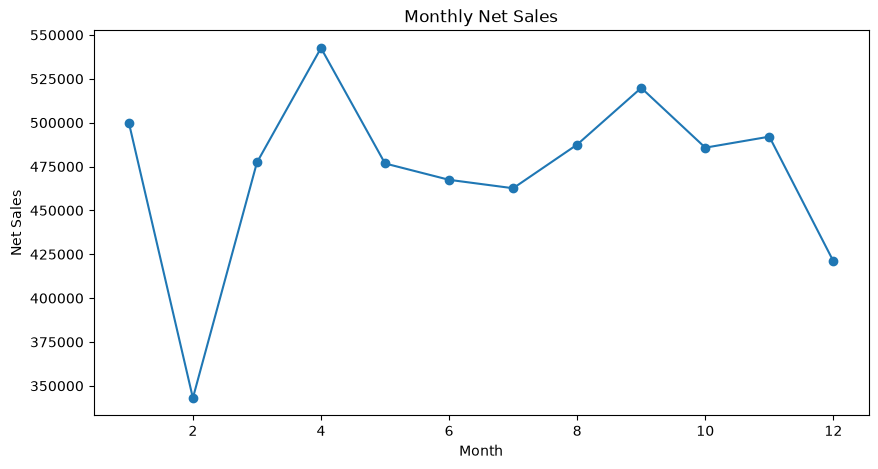

In [19]:
monthly=df.groupby('order_month')['net_sales'].sum()
monthly=monthly.sort_index()
monthly=monthly.to_frame()
monthly['pct_change']=monthly['net_sales'].pct_change()*100
monthly.tail(12)
plt.figure(figsize=(10,5))
plt.plot(monthly.index,monthly['net_sales'],marker='o')
plt.title("Monthly Net Sales")
plt.xlabel("Month")
plt.ylabel("Net Sales")
plt.show

## Question 12 — Top Customers

Create a customer summary containing:

- Number of unique orders
- Total net sales
- Total profit
- Average satisfaction score

Display the top 10 customers by total net sales.

In [20]:
summary_cr=df.groupby('customer_id').agg({'order_id':'nunique','net_sales':'sum','profit':'sum',
'satisfaction_score':'mean'})
summary_cr=summary_cr.sort_values(by='net_sales',ascending=False)
summary_cr.head(10)

,order_id,net_sales,profit,satisfaction_score
customer_id,,,,
C01003,3,"81,462.09","73,902.32",4.33
C00302,9,"28,434.31","5,684.40",4.11
C00488,6,"22,115.23","4,127.33",3.83
C00087,7,"21,516.70","7,916.98",3.71
C00794,6,"21,493.23","5,697.80",4.00
C00582,6,"19,984.49","6,049.47",4.50
C00356,5,"18,899.93","4,532.30",4.20
C00392,2,"18,600.68","8,106.19",4.50
C01225,4,"18,055.53","14,370.99",3.50


## Question 13 — Return Analysis

Calculate the return rate for each `category`.

Then create a bar chart showing the return rate percentage by category.

Which category has the highest return rate?

Category with highest return rate: Electronics


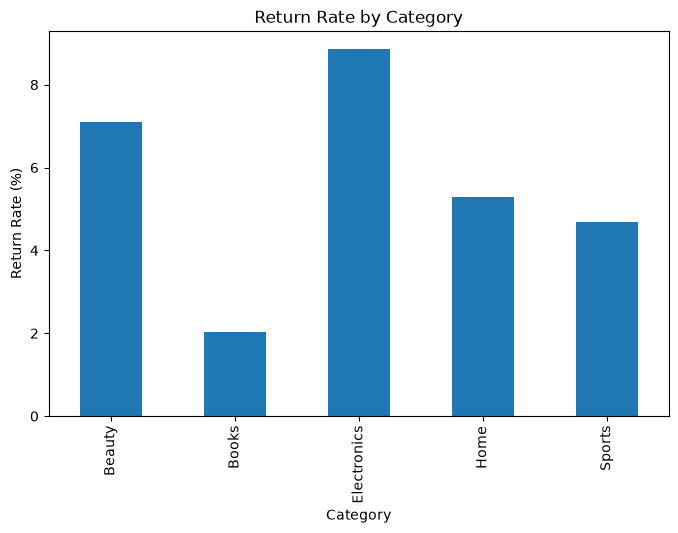

In [21]:
return_rate=df.groupby('category')['returned'].mean()*100
plt.figure(figsize=(8,5))
return_rate.plot(kind='bar')
plt.title("Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.show
print("Category with highest return rate:",return_rate.idxmax())

## Question 14 — Simple Outlier Detection

Use the IQR method on the complete `unit_price` column:

1. Calculate Q1, Q3, and IQR.
2. Define the lower and upper limits.
3. Create a DataFrame named `price_outliers`.
4. Display the number of outliers and the 10 highest outlier prices.

Do not calculate separate limits for each category.

In [22]:
Q1=df['unit_price'].quantile(0.25)
Q3=df['unit_price'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
higher=Q3+1.5*IQR
price_outliers=df[(df['unit_price']< lower)|(df['unit_price']>higher)]
print(len(price_outliers))
price_outliers.sort_values(by='unit_price',ascending=False).head(10)

530


,order_id,order_date,ship_date,customer_id,customer_segment,country,city,channel,device,campaign,category,subcategory,product_id,unit_price,unit_cost,quantity,discount_pct,shipping_cost,payment_method,returned,satisfaction_score,delivery_days,gross_sales,net_sales,total_cost,profit,order_month,sales_level
2604,ORD-002283,2024-11-25,2024-11-29,C01003,Small Business,Turkey,Istanbul,Website,Tablet,Organic,Electronics,Headphones,ELE-HEA-102,"15,898.09","1,025.11",6,0.16,18.00,Wallet,False,5.00,4,"95,388.54","79,754.36","6,168.66","73,585.70",11,Very High
2519,ORD-002363,2024-09-16,2024-09-17,C01225,Small Business,Iran,Mashhad,Website,Mobile,Search Ads,Electronics,Headphones,ELE-HEA-079,"15,802.53",893.73,1,0.05,6.14,Card,False,3.00,1,"15,802.53","14,939.71",899.87,"14,039.84",9,Very High
4289,ORD-001435,2025-04-10,2025-04-13,C01542,Corporate,Iran,Tabriz,Website,Desktop,Organic,Electronics,Headphones,ELE-HEA-125,"3,668.80",337.71,1,0.15,6.00,Card,False,5.00,3,"3,668.80","3,118.48",343.71,"2,774.77",4,Very High
4207,ORD-002535,2024-10-17,2024-10-21,C00244,Consumer,Turkey,Ankara,Mobile App,Android,Organic,Sports,Outdoor,SPO-OUT-145,"2,552.92",222.55,4,0.03,14.02,Card,False,5.00,4,"10,211.68","9,861.42",904.22,"8,957.20",10,Very High
3827,ORD-003916,2024-11-21,2024-11-27,C00461,Corporate,Germany,Frankfurt,Mobile App,Android,Organic,Home,Kitchen,HOM-KIT-058,"1,834.78",81.58,1,0.14,12.48,Card,False,5.00,6,"1,834.78","1,581.95",94.06,"1,487.89",11,Very High
2810,ORD-003521,2025-10-24,2025-10-28,C01195,Consumer,Iran,Shiraz,Mobile App,iOS,Organic,Electronics,Headphones,ELE-HEA-072,"1,799.39","1,197.95",4,0.08,15.06,Card,False,4.00,4,"7,197.56","6,653.42","4,806.86","1,846.56",10,Very High
74,ORD-004611,2024-06-22,2024-06-25,C00969,Consumer,UAE,Abu Dhabi,Mobile App,iOS,Search Ads,Electronics,Monitor,ELE-MON-155,"1,799.16","1,230.88",2,0.11,13.45,Bank Transfer,False,5.00,3,"3,598.32","3,198.91","2,475.21",723.70,6,Very High
1795,ORD-001778,2025-11-15,2025-11-19,C01259,Corporate,Iran,Tehran,Mobile App,iOS,Organic,Electronics,Laptop,ELE-LAP-067,"1,799.13","1,367.31",1,0.16,8.96,Card,False,5.00,4,"1,799.13","1,516.31","1,376.27",140.04,11,Very High
2066,ORD-000189,2025-04-30,2025-05-03,C00163,Consumer,Iran,Tabriz,Marketplace,Desktop,Social Ads,Electronics,Mobile,ELE-MOB-053,"1,799.12","1,011.98",4,0.11,12.36,Wallet,False,5.00,3,"7,196.48","6,383.28","4,060.28","2,323.00",4,Very High
1892,ORD-003801,2025-05-27,2025-06-01,C00191,Consumer,Iran,Tabriz,Mobile App,Android,Organic,Electronics,Headphones,ELE-HEA-093,"1,798.36","1,214.35",4,0.07,12.64,Cash on Delivery,False,4.00,5,"7,193.44","6,671.20","4,870.04","1,801.16",5,Very High


## Question 15 — Final Visualization

Create a 2×2 figure containing:

1. Total net sales by category
2. Total profit by channel
3. Monthly net sales trend
4. Average satisfaction score by country

Add titles and axis labels. Below the code, write three short observations based
on the charts.

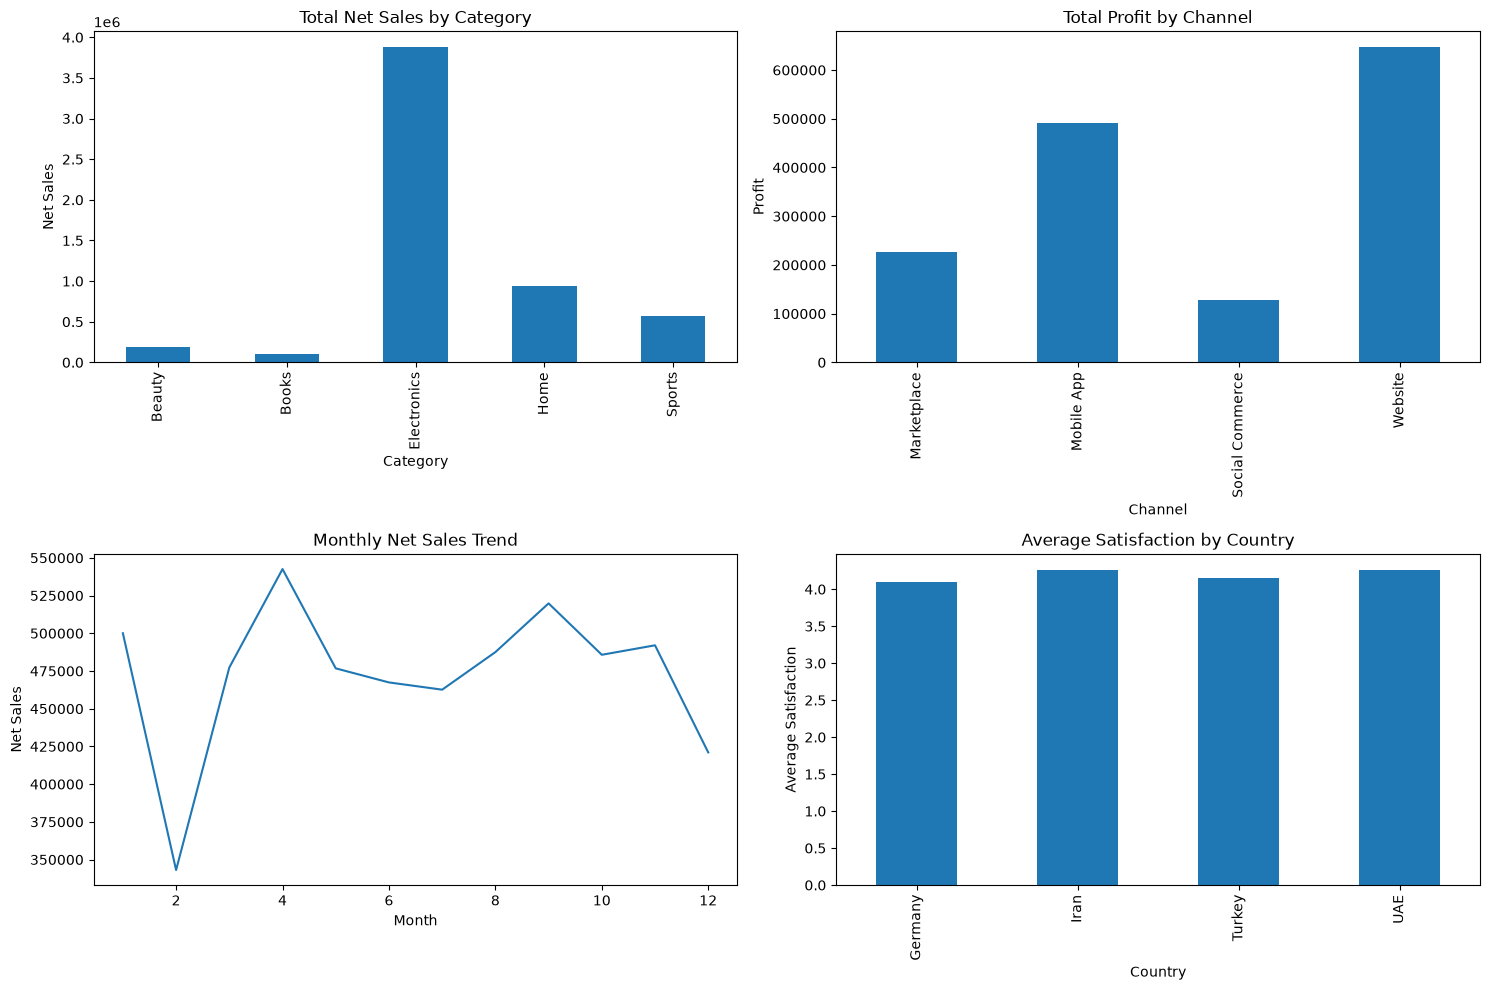

In [25]:
fig,axes=plt.subplots(2,2,figsize=(15,10))
category_sales=df.groupby('category')['net_sales'].sum()
category_sales.plot(kind='bar',ax=axes[0,0])
axes[0,0].set_title("Total Net Sales by Category")
axes[0,0].set_xlabel("Category")
axes[0,0].set_ylabel("Net Sales")
channel_profit=df.groupby('channel')['profit'].sum()
channel_profit.plot(kind='bar',ax=axes[0,1])
axes[0,1].set_title("Total Profit by Channel")
axes[0,1].set_xlabel("Channel")
axes[0,1].set_ylabel("Profit")
monthly_sales=df.groupby('order_month')['net_sales'].sum()
monthly_sales.plot(ax=axes[1,0])
axes[1,0].set_title("Monthly Net Sales Trend")
axes[1,0].set_xlabel("Month")
axes[1,0].set_ylabel("Net Sales")
country_sat=df.groupby('country')['satisfaction_score'].mean()
country_sat.plot(kind='bar',ax=axes[1,1])
axes[1,1].set_title("Average Satisfaction by Country")
axes[1,1].set_xlabel("Country")
axes[1,1].set_ylabel("Average Satisfaction")
plt.tight_layout()
plt.show()

## Final Check

Restart the kernel and run all cells before submitting your work. Make sure every
chart has a title and readable axis labels.
